In [1]:
import pandas as pd
import numpy as np

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [55]:
base_path = "/content/drive/MyDrive/Fall 2025/Responsible AI/RAI Project/Project Implementation"

df = pd.read_csv(base_path + '/nc_voted_with_predicted_party.csv')

In [ ]:
keys1 = ['W', 'B', 'A', 'HL']
values1 = [0.68, 0.5, 0.5, 0.54]
# values1 = [0.5, 0.5, 0.5, 0.5]

py_race_cutoffs = dict(zip(keys1, values1))

In [56]:
import numpy as np

prob_cols_list = ['prob_white', 'prob_black', 'prob_asian', 'prob_hisp']
q = 0.5
# Create a mapping from probability column names to race codes
prob_to_race_map = {
    'prob_white': 'W',
    'prob_black': 'B',
    'prob_asian': 'A',
    'prob_hisp': 'HL'
}

# Calculate the maximum probability and the column name corresponding to it
df['max_prob'] = df[prob_cols_list].max(axis=1)
df['max_prob_col'] = df[prob_cols_list].idxmax(axis=1)

# Apply the new logic for 'predicted_race'
df['predicted_race'] = np.where(
    df['max_prob'] > q,
    df['max_prob_col'].map(prob_to_race_map),
    'U'
)

# Drop the temporary columns
df.drop(columns=['max_prob', 'max_prob_col'], inplace=True)

print("New 'predicted_race' column created based on maximum probability and 0.5 threshold.")

/tmp/ipython-input-2014763858.py:15: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df['max_prob_col'] = df[prob_cols_list].idxmax(axis=1)


New 'predicted_race' column created based on maximum probability and 0.5 threshold.


In [ ]:
import numpy as np

# Define the order of priority and corresponding probability columns and thresholds
# race_priority_map = {
#     'W': 'prob_white',
#     'B': 'prob_black',
#     'A': 'prob_asian',
#     'HL': 'prob_hisp'
# }

# conditions = []
# choices = []

# for race_code, prob_col_name in race_priority_map.items():
#     conditions.append(df[prob_col_name] >= py_race_cutoffs[race_code])
#     choices.append(race_code)

# df['predicted_race'] = np.select(conditions, choices, default='U')

# Old code (commented out as requested)
df['predicted_race'] = 'U'
df.loc[df['prob_white'] >= py_race_cutoffs['W'], 'predicted_race'] = 'W'
df.loc[df['prob_black'] >= py_race_cutoffs['B'], 'predicted_race'] = 'B'
df.loc[df['prob_asian'] >= py_race_cutoffs['A'], 'predicted_race'] = 'A'
df.loc[df['prob_hisp'] >= py_race_cutoffs['HL'], 'predicted_race'] = 'HL'

In [57]:
races_to_keep = ['W', 'A', 'B', 'HL']
df.loc[~df['race_code'].isin(races_to_keep), 'race_code'] = 'U'

In [ ]:
print(q)

# Get value counts for predicted_race and race_code
predicted_race_counts = df['predicted_race'].value_counts().reindex(['W', 'B', 'A', 'HL', 'U'], fill_value=0)
race_code_counts = df['race_code'].value_counts().reindex(['W', 'B', 'A', 'HL', 'U'], fill_value=0)

# Create a DataFrame from the counts
comparison_df = pd.DataFrame({
    'predicted_race_count': predicted_race_counts,
    'race_code_count': race_code_counts
})

# Calculate the percentage difference
comparison_df['percentage_diff'] = ((comparison_df['predicted_race_count'] - comparison_df['race_code_count']) / comparison_df['race_code_count']) * 100

print("\nComparison of Predicted Race and True Race Counts:")
print(comparison_df.round(2))

0.5

Comparison of Predicted Race and True Race Counts:
    predicted_race_count  race_code_count  percentage_diff
W                 490305           465265             5.38
B                 138874           147863            -6.08
A                  12181            13443            -9.39
HL                 32245             5855           450.73
U                  86588           127767           -32.23


In [ ]:

df['pred_party'].unique()

array(['UNA', 'DEM', nan, 'REP'], dtype=object)

In [ ]:
print("Rows DataFrame shape:", df.shape)
df.dropna(subset=['pred_party'], inplace=True)
print("Rows with NaN in 'pred_party' removed. New DataFrame shape:", df.shape)

Rows DataFrame shape: (760193, 24)
Rows with NaN in 'pred_party' removed. New DataFrame shape: (731804, 24)


In [ ]:
print("Counts for predicted_race column:")
display(df['predicted_race'].value_counts().reindex(['W', 'B', 'A', 'HL', 'U']))

Counts for predicted_race column:


,count
predicted_race,
W,490305
B,138874
A,12181
HL,32245
U,86588


In [ ]:
print("\nCounts for race_code column:")
display(df['race_code'].value_counts().reindex(['W', 'B', 'A', 'HL', 'U']))


Counts for race_code column:


,count
race_code,
W,461808
B,147337
A,13373
HL,5812
U,65443


In [ ]:
df.to_csv("nc_voterdata_with_pred_party_and_race.csv")

In [35]:
races_to_keep = ['W', 'A', 'B', 'HL']
df.loc[~df['race_code'].isin(races_to_keep), 'race_code'] = 'U'

In [ ]:
def calculate_absgap_and_risk_ration(party, rc_p):

  if party in rc_p.columns:
      rep_max = rc_p[party].max()
      rep_min = rc_p[party].min()

      absolute_gap = rep_max - rep_min
      risk_ratio = rep_max / rep_min if rep_min > 0 else None

      print(f"\n=== Disparity ({party} predicted rate) ===")
      print(f"Absolute gap: {absolute_gap:.4f}")
      print(f"Risk ratio:   {risk_ratio:.4f}" if risk_ratio else "Risk ratio: N/A (division by zero)")

In [ ]:
#BASE LINE - ACTUAL RACE DISPARITY

In [ ]:
race_party = df.groupby("race_code")["pred_party"].value_counts(normalize=True).unstack()

In [ ]:
print(race_party)

pred_party       DEM       REP       UNA
race_code                               
A           0.287894  0.150602  0.561505
B           0.580621  0.105737  0.313642
HL          0.326566  0.154164  0.519270
U           0.220036  0.189584  0.590380
W           0.232653  0.370507  0.396840


In [ ]:
print("\n=== Predicted Party Distribution by Race ===")

calculate_absgap_and_risk_ration("REP", race_party)
calculate_absgap_and_risk_ration("DEM", race_party)
calculate_absgap_and_risk_ration("UNA", race_party)


=== Predicted Party Distribution by Race ===

=== Disparity (REP predicted rate) ===
Absolute gap: 0.2648
Risk ratio:   3.5040

=== Disparity (DEM predicted rate) ===
Absolute gap: 0.3606
Risk ratio:   2.6388

=== Disparity (UNA predicted rate) ===
Absolute gap: 0.2767
Risk ratio:   1.8823


In [ ]:
table = pd.crosstab(df['race_code'], df['pred_party'])
print("Race × Party Table:")
print(table)

Race × Party Table:
pred_party     DEM     REP     UNA
race_code                         
A             3850    2014    7509
B            85547   15579   46211
HL            1898     896    3018
U            22768   19617   61089
W           107441  171103  183264


In [ ]:
within_party = table.div(table.sum(axis=0), axis=1) * 100
print("\nWithin-party racial composition (%):")
print(within_party)


Within-party racial composition (%):
pred_party        DEM        REP        UNA
race_code                                  
A            1.738118   0.962674   2.493930
B           38.620973   7.446620  15.347852
HL           0.856869   0.428280   1.002355
U           10.278821   9.376748  20.289215
W           48.505219  81.785678  60.866648


In [ ]:
within_race = table.div(table.sum(axis=1), axis=0) * 100
print("\nWithin-race party affiliation (%):")
print(within_race)


Within-race party affiliation (%):
pred_party        DEM        REP        UNA
race_code                                  
A           28.789352  15.060196  56.150452
B           58.062130  10.573719  31.364152
HL          32.656573  15.416380  51.927047
U           22.003595  18.958386  59.038019
W           23.265296  37.050679  39.684025


In [ ]:
population_dist = df['race_code'].value_counts(normalize=True) * 100

# Disparity ratio: (party_share_of_race / population_share_of_race)
disparity_ratio = within_party.div(population_dist, axis=0)
print("\nDisparity Ratios:")
print(disparity_ratio)


Disparity Ratios:
pred_party       DEM       REP       UNA
race_code                               
A           0.982894  0.544386  1.410302
B           1.985581  0.382846  0.789063
HL          1.112530  0.556064  1.301423
U           0.611573  0.557901  1.207175
W           0.792523  1.336290  0.994496


In [ ]:
#RACE DISPARITY USING THRESHOLDED RACE VALUES

In [ ]:
race_party_th = df.groupby("predicted_race")["pred_party"].value_counts(normalize=True).unstack()
print(race_party_th)

pred_party           DEM       REP       UNA
predicted_race                              
A               0.276652  0.142228  0.581119
B               0.494615  0.150079  0.355307
HL              0.282472  0.190697  0.526831
U               0.318885  0.193397  0.487719
W               0.247788  0.350433  0.401779


In [ ]:
print("\n=== Predicted Party Distribution by Race ===")

calculate_absgap_and_risk_ration("REP", race_party_th)
calculate_absgap_and_risk_ration("DEM", race_party_th)
calculate_absgap_and_risk_ration("UNA", race_party_th)


=== Predicted Party Distribution by Race ===

=== Disparity (REP predicted rate) ===
Absolute gap: 0.2082
Risk ratio:   2.4639

=== Disparity (DEM predicted rate) ===
Absolute gap: 0.2468
Risk ratio:   1.9961

=== Disparity (UNA predicted rate) ===
Absolute gap: 0.2258
Risk ratio:   1.6355


In [ ]:
table_th = pd.crosstab(df['predicted_race'], df['pred_party'])
print("Race × Party Table:")
print(table_th)

Race × Party Table:
pred_party         DEM     REP     UNA
predicted_race                        
A                 3332    1713    6999
B                65713   19939   47205
HL                8775    5924   16366
U                26705   16196   40844
W               116979  165437  189677


In [ ]:
within_party_th = table_th.div(table_th.sum(axis=0), axis=1) * 100
print("\nWithin-party racial composition (%):")
print(within_party_th)


Within-party racial composition (%):
pred_party            DEM        REP        UNA
predicted_race                                 
A                1.504262   0.818798   2.324546
B               29.666733   9.530661  15.677984
HL               3.961554   2.831618   5.435566
U               12.056216   7.741541  13.565334
W               52.811236  79.077382  62.996569


In [ ]:
population_dist_th = df['predicted_race'].value_counts(normalize=True) * 100

# Disparity ratio: (party_share_of_race / population_share_of_race)
disparity_ratio_th = within_party_th.div(population_dist_th, axis=0)
print("\nDisparity Ratios:")
print(disparity_ratio_th)


Disparity Ratios:
pred_party           DEM       REP       UNA
predicted_race                              
A               0.938781  0.510996  1.450705
B               1.623950  0.521706  0.858209
HL              0.933957  0.667569  1.281464
U               1.058467  0.679663  1.190959
W               0.818811  1.226055  0.976730


In [ ]:
#RACE DISPARITY USING WEIGHING

In [ ]:
def true_disparity(df, race_col='race_code', outcome_col='party', reference='white'):
    results = {}
    ref_mean = df.loc[df[race_col] == reference, outcome_col].mean()

    for g in df[race_col].unique():
        group_mean = df.loc[df[race_col] == g, outcome_col].mean()
        results[g] = group_mean - ref_mean

    return pd.DataFrame({'True Disparity (vs ref)': results})

In [ ]:
def thresholded_disparity(df, outcome_col='party', reference='white'):
    results = {}
    print(len(df))
    assigned = df.dropna(subset=['predicted_race'])
    print(len(assigned))
    ref_mean = assigned.loc[assigned['predicted_race']==reference, outcome_col].mean()

    for g in assigned['predicted_race'].unique():
        group_mean = assigned.loc[assigned['predicted_race']==g, outcome_col].mean()
        results[g] = group_mean - ref_mean

    return pd.DataFrame({'Thresholded Disparity': results})


In [ ]:
#The paper's way of thresholding
def bisg_thresholded_assignment(df, prob_cols, q=0.5):
    df = df.copy()

    race_code_map = {
        'white': 'W',
        'black': 'B',
        'asian': 'A',
        'hisp': 'HL'
    }

    df["bisg_race_thresh"] = None
    for prob_key, prob_col_name in prob_cols.items():
        assigned_code = race_code_map.get(prob_key)
        if assigned_code:
            df.loc[df[prob_col_name] > q, "bisg_race_thresh"] = assigned_code

    return df

def thresholded_disparity(df, target_party=None, reference='W'):
    results = {}
    assigned = df.dropna(subset=['bisg_race_thresh'])
    ref_mean = (assigned.loc[assigned['bisg_race_thresh']==reference, 'pred_party'] == target_party).mean()

    for g in assigned['bisg_race_thresh'].unique():
        group_mean = (assigned.loc[assigned['bisg_race_thresh']==g, 'pred_party'] == target_party).mean()
        results[g] = group_mean - ref_mean

    return pd.DataFrame({f'Thresholded Disparity ({target_party} vs {reference})': results})

In [ ]:
def true_disparity(df, race_col='race_code', target_party=None, reference='W'):
    results = {}
    # Calculate the proportion of target_party for the reference group
    ref_proportion = (df.loc[df[race_col] == reference, 'pred_party'] == target_party).mean()

    for g in df[race_col].unique():
        group_proportion = (df.loc[df[race_col] == g, 'pred_party'] == target_party).mean()
        results[g] = group_proportion - ref_proportion
        # results[g] = group_proportion

    return pd.DataFrame({f'True Disparity ({target_party} vs {reference})': results})

In [ ]:
def thresholded_disparity(df, target_party=None, reference='W'):
    results = {}
    print(len(df))
    # assigned = df.dropna(subset=['predicted_race'])
    assigned = df.copy()
    print(len(assigned))
    # Calculate the proportion of target_party for the reference group in assigned (predicted_race)
    ref_proportion = (assigned.loc[assigned['predicted_race'] == reference, 'pred_party'] == target_party).mean()

    for g in assigned['predicted_race'].unique():
        group_proportion = (assigned.loc[assigned['predicted_race'] == g, 'pred_party'] == target_party).mean()
        # results[g] = group_proportion
        results[g] = group_proportion - ref_proportion

    return pd.DataFrame({f'Thresholded Disparity ({target_party} vs {reference})': results})

In [ ]:
def weighted_bisg_disparity(df, prob_cols, outcome_col=None, reference='white'):
    results = {}
    # reference mean
    ref_weights = df[prob_cols[reference]]
    ref_mu = (ref_weights * df[outcome_col]).sum() / ref_weights.sum()

    for g, col in prob_cols.items():
        weights = df[col]
        mu_g = (weights * df[outcome_col]).sum() / weights.sum()
        results[g] = mu_g - ref_mu
        # results[g] = mu_g

    return pd.DataFrame({'Weighted Disparity': results})


In [ ]:
# Mapping race names to column names
prob_cols = {
    'white': 'prob_white',
    'black': 'prob_black',
    'asian': 'prob_asian',
    'hisp':  'prob_hisp'
}

parties = ['DEM', 'REP', 'UNA']
reference_race_code = 'W'
reference_predicted_race = 'W'
reference_prob_col = 'white'

print("### 1. TRUE DISPARITY ###")
for party in parties:
    true_disp = true_disparity(df, race_col='race_code', target_party=party, reference=reference_race_code)
    print(true_disp)

print("\n### 2. THRESHOLDED BISG DISPARITY ###")
for party in parties:
    # df2 = bisg_thresholded_assignment(df, prob_cols, q=0.8)
    # thresh_disp = thresholded_disparity(df2, target_party=party, reference=reference_predicted_race)
    thresh_disp = thresholded_disparity(df, target_party=party, reference=reference_predicted_race)
    print(thresh_disp)

print("\n### 3. WEIGHTED BISG DISPARITY ###")
for party in parties:
    temp_df = df.copy()
    temp_df[f'is_{party.lower()}'] = (temp_df['pred_party'] == party).astype(int)
    weighted_disp = weighted_bisg_disparity(temp_df, prob_cols, outcome_col=f'is_{party.lower()}', reference=reference_prob_col)
    print(weighted_disp.rename(columns={'Weighted Disparity': f'Weighted Disparity ({party} vs {reference_prob_col})'}))

### 1. TRUE DISPARITY ###
    True Disparity (DEM vs W)
U                   -0.052725
W                    0.000000
B                    0.347632
A                    0.055470
HL                   0.093243
    True Disparity (REP vs W)
U                   -0.214217
W                    0.000000
B                   -0.262393
A                   -0.217936
HL                  -0.214722
    True Disparity (UNA vs W)
U                    0.084237
W                    0.000000
B                   -0.081366
A                    0.164689
HL                   0.121565

### 2. THRESHOLDED BISG DISPARITY ###
760193
760193
    Thresholded Disparity (DEM vs W)
U                           0.115946
W                           0.000000
B                           0.276092
A                           0.048407
HL                          0.049438
760193
760193
    Thresholded Disparity (REP vs W)
U                          -0.130345
W                           0.000000
B                          -0.2340

In [ ]:
# Mapping race names to column names
prob_cols = {
    'white': 'prob_white',
    'black': 'prob_black',
    'asian': 'prob_asian',
    'hisp':  'prob_hisp'
}

parties = ['DEM', 'REP', 'UNA']
reference_race_code = 'W'
reference_predicted_race = 'W'
reference_prob_col = 'white'

print("### 1. TRUE DISPARITY ###")
for party in parties:
    true_disp = true_disparity(df, race_col='race_code', target_party=party, reference=reference_race_code)
    print(true_disp)

print("\n### 2. THRESHOLDED BISG DISPARITY ###")
for party in parties:
    # df2 = bisg_thresholded_assignment(df, prob_cols, q=0.8)
    # thresh_disp = thresholded_disparity(df2, target_party=party, reference=reference_predicted_race)
    thresh_disp = thresholded_disparity(df, target_party=party, reference=reference_predicted_race)
    print(thresh_disp)

print("\n### 3. WEIGHTED BISG DISPARITY ###")
for party in parties:
    # Create a temporary numerical column for the current party
    temp_df = df.copy()
    temp_df[f'is_{party.lower()}'] = (temp_df['pred_party'] == party).astype(int)
    weighted_disp = weighted_bisg_disparity(temp_df, prob_cols, outcome_col=f'is_{party.lower()}', reference=reference_prob_col)
    # Adjust the output column name for clarity
    print(weighted_disp.rename(columns={'Weighted Disparity': f'Weighted Disparity ({party} vs {reference_prob_col})'}))

In [ ]:
base_path = "/content/drive/MyDrive/Fall 2025/Responsible AI/RAI Project/Project Implementation"

df = pd.read_csv(base_path + '/real_bisg_done_sample_26245.csv')

In [ ]:
# import numpy as np

# prob_cols_list = ['prob_white', 'prob_black', 'prob_asian', 'prob_hisp']

# # Create a mapping from probability column names to race codes
# prob_to_race_map = {
#     'prob_white': 'W',
#     'prob_black': 'B',
#     'prob_asian': 'A',
#     'prob_hisp': 'HL'
# }

# # Find the column with the maximum probability for each row and map it to the race code
# df['predicted_race'] = df[prob_cols_list].idxmax(axis=1).map(prob_to_race_map)

# print("New 'predicted_race' column created based on maximum probability.")



prob_cols_list = ['prob_white', 'prob_black', 'prob_asian', 'prob_hisp']

# Create a mapping from probability column names to race codes
prob_to_race_map = {
    'prob_white': 'W',
    'prob_black': 'B',
    'prob_asian': 'A',
    'prob_hisp': 'HL'
}

# Calculate the maximum probability and the column name corresponding to it
df['max_prob'] = df[prob_cols_list].max(axis=1)
df['max_prob_col'] = df[prob_cols_list].idxmax(axis=1)

# Apply the new logic for 'predicted_race'
df['predicted_race'] = np.where(
    df['max_prob'] > 0.7,
    df['max_prob_col'].map(prob_to_race_map),
    'U'
)

# Drop the temporary columns
df.drop(columns=['max_prob', 'max_prob_col'], inplace=True)

print("New 'predicted_race' column created based on maximum probability and 0.5 threshold.")

New 'predicted_race' column created based on maximum probability and 0.5 threshold.


/tmp/ipython-input-3752898977.py:32: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df['max_prob_col'] = df[prob_cols_list].idxmax(axis=1)


In [ ]:
races_to_keep = ['W', 'A', 'B', 'HL']
df.loc[~df['race_code'].isin(races_to_keep), 'race_code'] = 'U'

In [ ]:
df = df[df['predicted_race'] != 'U'].copy()
df = df[df['race_code'] != 'U'].copy()
print(f"DataFrame shape after dropping 'U' from predicted_race: {df.shape}")

DataFrame shape after dropping 'U' from predicted_race: (15219, 22)


In [ ]:
print(df['predicted_race'].value_counts())
print("TRUE RACE COUNT")
print(df['race_code'].value_counts())

predicted_race
W     12321
B      2181
HL      422
A       295
Name: count, dtype: int64
TRUE RACE COUNT
race_code
W     12030
B      2678
A       358
HL      153
Name: count, dtype: int64


In [ ]:
def true_disparity(df, race_col='race_code', target_party=None, reference='W'):
    results = {}
    # Calculate the proportion of target_party for the reference group
    ref_proportion = (df.loc[df[race_col] == reference, 'party_cd'] == target_party).mean()

    for g in df[race_col].unique():
        group_proportion = (df.loc[df[race_col] == g, 'party_cd'] == target_party).mean()
        results[g] = group_proportion - ref_proportion

    return pd.DataFrame({f'True Disparity ({target_party} vs {reference})': results})

In [ ]:
# def bisg_thresholded_assignment(df, prob_cols, q=0.5):
#     df = df.copy()

#     race_code_map = {
#         'white': 'W',
#         'black': 'B',
#         'asian': 'A',
#         'hisp': 'HL'
#     }

#     df["bisg_race_thresh"] = None
#     for prob_key, prob_col_name in prob_cols.items():
#         assigned_code = race_code_map.get(prob_key)
#         if assigned_code:
#             df.loc[df[prob_col_name] > q, "bisg_race_thresh"] = assigned_code

#     return df

# def thresholded_disparity(df, target_party=None, reference='W'):
#     results = {}
#     assigned = df.dropna(subset=['bisg_race_thresh'])
#     ref_mean = (assigned.loc[assigned['bisg_race_thresh']==reference, 'party_cd'] == target_party).mean()

#     for g in assigned['bisg_race_thresh'].unique():
#         group_mean = (assigned.loc[assigned['bisg_race_thresh']==g, 'party_cd'] == target_party).mean()
#         results[g] = group_mean - ref_mean

#     return pd.DataFrame({f'Thresholded Disparity ({target_party} vs {reference})': results})

In [ ]:
def thresholded_disparity(df, target_party=None, reference='W'):
    results = {}
    assigned = df.dropna(subset=['predicted_race'])
    # Calculate the proportion of target_party for the reference group in assigned (predicted_race)
    ref_proportion = (assigned.loc[assigned['predicted_race'] == reference, 'party_cd'] == target_party).mean()

    for g in assigned['predicted_race'].unique():
        group_proportion = (assigned.loc[assigned['predicted_race'] == g, 'party_cd'] == target_party).mean()
        results[g] = group_proportion - ref_proportion

    return pd.DataFrame({f'Thresholded Disparity ({target_party} vs {reference})': results})

In [ ]:
def weighted_bisg_disparity(df, prob_cols, outcome_col='party', reference='white'):
    results = {}

    # reference mean
    ref_weights = df[prob_cols[reference]]
    ref_mu = (ref_weights * df[outcome_col]).sum() / ref_weights.sum()

    for g, col in prob_cols.items():
        weights = df[col]
        mu_g = (weights * df[outcome_col]).sum() / weights.sum()
        results[g] = mu_g - ref_mu

    return pd.DataFrame({'Weighted Disparity': results})

In [ ]:
# Mapping race names to column names
prob_cols = {
    'white': 'prob_white',
    'black': 'prob_black',
    'asian': 'prob_asian',
    'hisp':  'prob_hisp'
}

parties = ['DEM', 'REP', 'UNA']
reference_race_code = 'W'
reference_predicted_race = 'W'
reference_prob_col = 'white'

print("### 1. TRUE DISPARITY ###")
for party in parties:
    true_disp = true_disparity(df, race_col='race_code', target_party=party, reference=reference_race_code)
    print(true_disp)

print("\n### 2. THRESHOLDED BISG DISPARITY ###")
for party in parties:
    # df2 = bisg_thresholded_assignment(df, prob_cols, q=0.6)
    # thresh_disp = thresholded_disparity(df2, target_party=party, reference=reference_predicted_race)
    thresh_disp = thresholded_disparity(df, target_party=party, reference=reference_predicted_race)
    print(thresh_disp)

print("\n### 3. WEIGHTED BISG DISPARITY ###")
for party in parties:
    # Create a temporary numerical column for the current party
    temp_df = df.copy()
    temp_df[f'is_{party.lower()}'] = (temp_df['party_cd'] == party).astype(int)
    weighted_disp = weighted_bisg_disparity(temp_df, prob_cols, outcome_col=f'is_{party.lower()}', reference=reference_prob_col)
    # Adjust the output column name for clarity
    print(weighted_disp.rename(columns={'Weighted Disparity': f'Weighted Disparity ({party} vs {reference_prob_col})'}))

### 1. TRUE DISPARITY ###
    True Disparity (DEM vs W)
W                    0.000000
B                    0.542000
A                    0.056058
HL                   0.208017
    True Disparity (REP vs W)
W                    0.000000
B                   -0.380036
A                   -0.213215
HL                  -0.239340
    True Disparity (UNA vs W)
W                    0.000000
B                   -0.159305
A                    0.156201
HL                   0.038201

### 2. THRESHOLDED BISG DISPARITY ###
    Thresholded Disparity (DEM vs W)
W                           0.000000
B                           0.378168
A                           0.021310
HL                          0.103565
    Thresholded Disparity (REP vs W)
W                           0.000000
B                          -0.263619
A                          -0.201902
HL                         -0.163842
    Thresholded Disparity (UNA vs W)
W                           0.000000
B                          -0.112423
A   

In [ ]:
base_path = "/content/drive/MyDrive/Fall 2025/Responsible AI/RAI Project/Project Implementation"

df = pd.read_csv(base_path + '/nc_voted_with_predicted_party.csv')

In [ ]:
df['party_cd'].unique()

array(['UNA', 'DEM', 'REP'], dtype=object)

In [ ]:
len(df)

731804

In [ ]:
df.dropna(subset=['race_code'], inplace=True)

In [ ]:
df.dropna(subset=['pred_party'], inplace=True)

In [ ]:
races_to_keep = ['W', 'A', 'B', 'HL']
df.loc[~df['race_code'].isin(races_to_keep), 'race_code'] = 'U'

In [ ]:
race_map = {
    "W": "white",
    "B": "black",
    "HL": "hisp",
    "A": "asian",
    "U": "unknown"
}

df["true_race_clean"] = df["race_code"].map(race_map)

In [ ]:
def compute_disparities(df, race_a, race_b, outcome_col="Y", q=0.7):

    # ---- TRUE DISPARITY ----
    true_mu_a = df.loc[df["true_race_clean"] == race_a, outcome_col].mean()
    true_mu_b = df.loc[df["true_race_clean"] == race_b, outcome_col].mean()
    true_disparity = true_mu_a - true_mu_b

    # ---- THRESHOLDED ESTIMATOR ----
    race_cols = ["prob_white", "prob_black", "prob_asian", "prob_hisp"]

    df["est_race_q"] = df[race_cols].apply(
        lambda row: row.idxmax().replace("prob_", "") if row.max() > q else None,
        axis=1
    )

    df_q = df.dropna(subset=["est_race_q"])

    thresh_mu_a = df_q.loc[df_q["est_race_q"] == race_a, outcome_col].mean()
    thresh_mu_b = df_q.loc[df_q["est_race_q"] == race_b, outcome_col].mean()
    threshold_disparity = thresh_mu_a - thresh_mu_b

    # ---- WEIGHTED ESTIMATOR ----
    w_a = df[f"prob_{race_a}"]
    w_b = df[f"prob_{race_b}"]

    weighted_mu_a = (w_a * df[outcome_col]).sum() / w_a.sum()
    weighted_mu_b = (w_b * df[outcome_col]).sum() / w_b.sum()
    weighted_disparity = weighted_mu_a - weighted_mu_b

    return pd.DataFrame({"estimator": ["true", "threshold", "weighted"],
                         "disparity": [true_disparity, threshold_disparity, weighted_disparity]})

In [ ]:
df["Y"] = (df["pred_party"] == "DEM").astype(int)

results = compute_disparities(df, race_a="hisp", race_b="white", q=0.2)
print(results)

df["Y"] = (df["pred_party"] == "REP").astype(int)

results = compute_disparities(df, race_a="hisp", race_b="white", q=0.2)
print(results)

df["Y"] = (df["pred_party"] == "UNA").astype(int)

results = compute_disparities(df, race_a="hisp", race_b="white", q=0.2)
print(results)

   estimator  disparity
0       true   0.093913
1  threshold   0.034600
2   weighted   0.034238
   estimator  disparity
0       true  -0.216343
1  threshold  -0.158762
2   weighted  -0.144986
   estimator  disparity
0       true   0.122430
1  threshold   0.124162
2   weighted   0.110748


# Task
Combine the disparity results from `true_disparity`, `thresholded_disparity`, and `weighted_bisg_disparity` functions for all parties into a single pandas DataFrame. The DataFrame should have race categories (W, B, A, HL, U) as columns and the disparity methods (True, Thresholded, Weighted) for each party as rows. Ensure consistent column naming, handle missing 'U' categories for weighted disparity by setting them to NaN, and print the final consolidated disparity table.

## Consolidate Disparity Results

### Subtask:
Combine the results from 'true_disparity', 'thresholded_disparity', and 'weighted_bisg_disparity' functions for all parties into a single pandas DataFrame. The DataFrame should have race categories (W, B, A, HL, U) as columns and the disparity methods (True, Thresholded, Weighted) for each party as rows. Ensure consistent column naming and handle missing 'U' categories for weighted disparity.


**Reasoning**:
The subtask requires consolidating disparity results from 'true_disparity', 'thresholded_disparity', and 'weighted_bisg_disparity' functions for all parties into a single pandas DataFrame. This step initializes necessary variables and defines the main loop to calculate and collect these disparities.



In [ ]:
all_disparities_data = []

prob_cols = {
    'white': 'prob_white',
    'black': 'prob_black',
    'asian': 'prob_asian',
    'hisp':  'prob_hisp'
}

parties = ['DEM', 'REP', 'UNA']
reference_race_code = 'W'
reference_predicted_race = 'W'
reference_prob_col = 'white'

for party in parties:
    temp_df = df.copy()
    temp_df[f'is_{party.lower()}'] = (temp_df['pred_party'] == party).astype(int)

    # Calculate true disparity
    true_disp = true_disparity(df, race_col='race_code', target_party=party, reference=reference_race_code)
    true_disp_series = true_disp.iloc[:, 0].rename(index={'W':'W', 'B':'B', 'A':'A', 'HL':'HL', 'U':'U'})

    # Calculate thresholded disparity
    thresh_disp = thresholded_disparity(df, target_party=party, reference=reference_predicted_race)
    thresh_disp_series = thresh_disp.iloc[:, 0].rename(index={'W':'W', 'B':'B', 'A':'A', 'HL':'HL', 'U':'U'})

    # Calculate weighted disparity
    weighted_disp = weighted_bisg_disparity(temp_df, prob_cols, outcome_col=f'is_{party.lower()}', reference=reference_prob_col)
    # Rename index for consistency
    weighted_disp_series = weighted_disp.iloc[:, 0].rename(index={
        'white': 'W',
        'black': 'B',
        'asian': 'A',
        'hisp': 'HL'
    })
    # Add 'U' category with NaN for weighted disparity if not present
    if 'U' not in weighted_disp_series.index:
        weighted_disp_series.loc['U'] = np.nan

    # Append results to the list
    all_disparities_data.append({
        'Method': 'True',
        'Party': party,
        **true_disp_series.to_dict()
    })
    all_disparities_data.append({
        'Method': 'Thresholded',
        'Party': party,
        **thresh_disp_series.to_dict()
    })
    all_disparities_data.append({
        'Method': 'Weighted',
        'Party': party,
        **weighted_disp_series.to_dict()
    })
    print(all_disparities_data)

760193
760193
[{'Method': 'True', 'Party': 'DEM', 'U': -0.05272493339497536, 'W': 0.0, 'B': 0.34763151337354026, 'A': 0.0554700940593095, 'HL': 0.0932430663578839}, {'Method': 'Thresholded', 'Party': 'DEM', 'U': 0.11594582107158163, 'W': 0.0, 'B': 0.27609155042705874, 'A': 0.04840719236794844, 'HL': 0.04943761459006207}, {'Method': 'Weighted', 'Party': 'DEM', 'W': 0.0, 'B': 0.17879551469601737, 'A': 0.034078077825606984, 'HL': 0.03312048794016351, 'U': nan}]
760193
760193
[{'Method': 'True', 'Party': 'DEM', 'U': -0.05272493339497536, 'W': 0.0, 'B': 0.34763151337354026, 'A': 0.0554700940593095, 'HL': 0.0932430663578839}, {'Method': 'Thresholded', 'Party': 'DEM', 'U': 0.11594582107158163, 'W': 0.0, 'B': 0.27609155042705874, 'A': 0.04840719236794844, 'HL': 0.04943761459006207}, {'Method': 'Weighted', 'Party': 'DEM', 'W': 0.0, 'B': 0.17879551469601737, 'A': 0.034078077825606984, 'HL': 0.03312048794016351, 'U': nan}, {'Method': 'True', 'Party': 'REP', 'U': -0.21421656233961306, 'W': 0.0, 'B

**Reasoning**:
The previous step collected all disparity data into a list of dictionaries. Now, I will convert this list into a pandas DataFrame and ensure the columns are ordered as specified in the instructions, which will complete the subtask.



In [ ]:
import pandas as pd

# Concatenate the list of dictionaries into a single pandas DataFrame
consolidated_disparities_df = pd.DataFrame(all_disparities_data)

# Define the desired column order, ensuring 'U' is included
desired_columns = ['Method', 'Party', 'W', 'B', 'A', 'HL', 'U']

# Reindex the DataFrame to match the desired column order
consolidated_disparities_df = consolidated_disparities_df[desired_columns]

# Print the final consolidated disparity table
print("\nConsolidated Disparity Table:")
print(consolidated_disparities_df.round(4))



Consolidated Disparity Table:
        Method Party    W       B       A      HL       U
0         True   DEM  0.0  0.3476  0.0555  0.0932 -0.0527
1  Thresholded   DEM  0.0  0.2761  0.0484  0.0494  0.1159
2     Weighted   DEM  0.0  0.1788  0.0341  0.0331     NaN
3         True   REP  0.0 -0.2624 -0.2179 -0.2147 -0.2142
4  Thresholded   REP  0.0 -0.2341 -0.2090 -0.1690 -0.1303
5     Weighted   REP  0.0 -0.1452 -0.1822 -0.1394     NaN
6         True   UNA  0.0 -0.0814  0.1647  0.1216  0.0842
7  Thresholded   UNA  0.0 -0.0453  0.1862  0.1194  0.0097
8     Weighted   UNA  0.0 -0.0368  0.1735  0.1069     NaN


## Summary:

### Data Analysis Key Findings
*   Disparity results for 'DEM', 'REP', and 'UNA' parties were consolidated from three methods: True, Thresholded, and Weighted.
*   For each party, `true_disparity` and `thresholded_disparity` were calculated, yielding disparity values across 'W', 'B', 'A', 'HL', and 'U' race categories.
*   `weighted_bisg_disparity` was calculated for each party, providing disparity values for 'W', 'B', 'A', and 'HL' race categories. The 'U' (Unknown) category for weighted disparity was consistently set to `NaN` due to its inherent nature.
*   All calculated disparities were combined into a single DataFrame, `consolidated_disparities_df`, structured with disparity methods and parties as rows, and race categories ('W', 'B', 'A', 'HL', 'U') as columns.
*   The final consolidated disparity table was printed, with values rounded to four decimal places, presenting a unified view of the different disparity metrics.

### Insights or Next Steps
*   The consolidated table provides a comprehensive overview, allowing for direct comparison of different disparity measurement methods (True, Thresholded, Weighted) across various political parties and racial groups, which is crucial for assessing fairness.
*   Further investigation could explore the implications of `NaN` values for the 'U' category in the weighted disparity method, potentially requiring alternative approaches for handling unknown race categories when using probabilistic weighting.


In [58]:
import pandas as pd

def accuracy_by_true_race(df, races):
    results = {}
    for r in races:
        group = df[df["race_code"] == r]
        acc = (group["pred_party"] == group["party_cd"]).mean()
        results[r] = acc
    return pd.Series(results, name="Accuracy_TrueRace")

def acc_by_race_party_true(df, races=["W","B","HL","A"], parties=["DEM","REP","UNA"]):
    rows = []
    for r in races:
        for p in parties:
            subset = df[(df["race_code"] == r) & (df["party_cd"] == p)]
            if len(subset) == 0:
                acc = None
            else:
                acc = (subset["pred_party"] == subset["party_cd"]).mean()
            rows.append([r, p, acc])
    return pd.DataFrame(rows, columns=["Race", "Party", "Acc_TrueRace"])




In [59]:
def accuracy_by_bisg_thresh(df, races):
    results = {}
    for r in races:
        group = df[df["predicted_race"] == r]
        acc = (group["pred_party"] == group["party_cd"]).mean()
        results[r] = acc
    return pd.Series(results, name="Accuracy_BISG_Threshold")

def acc_by_race_party_thresh(df, races=["W","B","HL","A"], parties=["DEM","REP","UNA"]):
    rows = []
    for r in races:
        for p in parties:
            subset = df[(df["predicted_race"] == r) & (df["party_cd"] == p)]
            if len(subset) == 0:
                acc = None
            else:
                acc = (subset["pred_party"] == subset["party_cd"]).mean()
            rows.append([r, p, acc])
    return pd.DataFrame(rows, columns=["Race", "Party", "Acc_BISG_Threshold"])




In [60]:
def accuracy_weighted_bisg(df, races, prob_cols):
    results = {}

    correct = (df["pred_party"] == df["party_cd"]).astype(int)

    for r in races:
        p = df[prob_cols[r]]
        weighted_correct = (p * correct).sum()
        weight_total = p.sum()
        acc = weighted_correct / weight_total if weight_total > 0 else None
        results[r] = acc

    return pd.Series(results, name="Accuracy_WeightedBISG")

prob_map = {
    "W": "prob_white",
    "B": "prob_black",
    "HL": "prob_hisp",
    "A": "prob_asian"
}

def acc_by_race_party_weighted(df, races=["W","B","HL","A"], parties=["DEM","REP","UNA"]):
    rows = []
    correct = (df["pred_party"] == df["party_cd"]).astype(int)

    for r in races:
        w = df[prob_map[r]]  # weights for race r

        for p in parties:
            mask = (df["party_cd"] == p)

            w_sub = w[mask]
            cw = (correct[mask] * w_sub)

            if w_sub.sum() == 0:
                acc = None
            else:
                acc = cw.sum() / w_sub.sum()

            rows.append([r, p, acc])

    return pd.DataFrame(rows, columns=["Race", "Party", "Acc_Weighted"])


In [61]:
df_true = acc_by_race_party_true(df)
df_thresh = acc_by_race_party_thresh(df)
df_weight = acc_by_race_party_weighted(df)

final = df_true.merge(df_thresh, on=["Race", "Party"]).merge(df_weight, on=["Race", "Party"])

print(final)

   Race Party  Acc_TrueRace  Acc_BISG_Threshold  Acc_Weighted
0     W   DEM      0.729911            0.717298      0.720490
1     W   REP      0.729064            0.727152      0.727532
2     W   UNA      0.761407            0.766563      0.767505
3     B   DEM      0.739608            0.748481      0.743090
4     B   REP      0.579733            0.663017      0.687631
5     B   UNA      0.731750            0.767773      0.764878
6    HL   DEM      0.642601            0.636599      0.647332
7    HL   REP      0.614267            0.643516      0.653098
8    HL   UNA      0.786195            0.797737      0.794479
9     A   DEM      0.630597            0.624099      0.632218
10    A   REP      0.545646            0.541879      0.559118
11    A   UNA      0.782993            0.793578      0.791053


    Accuracy_TrueRace  Accuracy_BISG_Threshold  Accuracy_WeightedBISG
W            0.736428                 0.712811               0.713432
B            0.730129                 0.712005               0.709982
A            0.694413                 0.697890               0.697679
HL           0.703501                 0.690929               0.692305


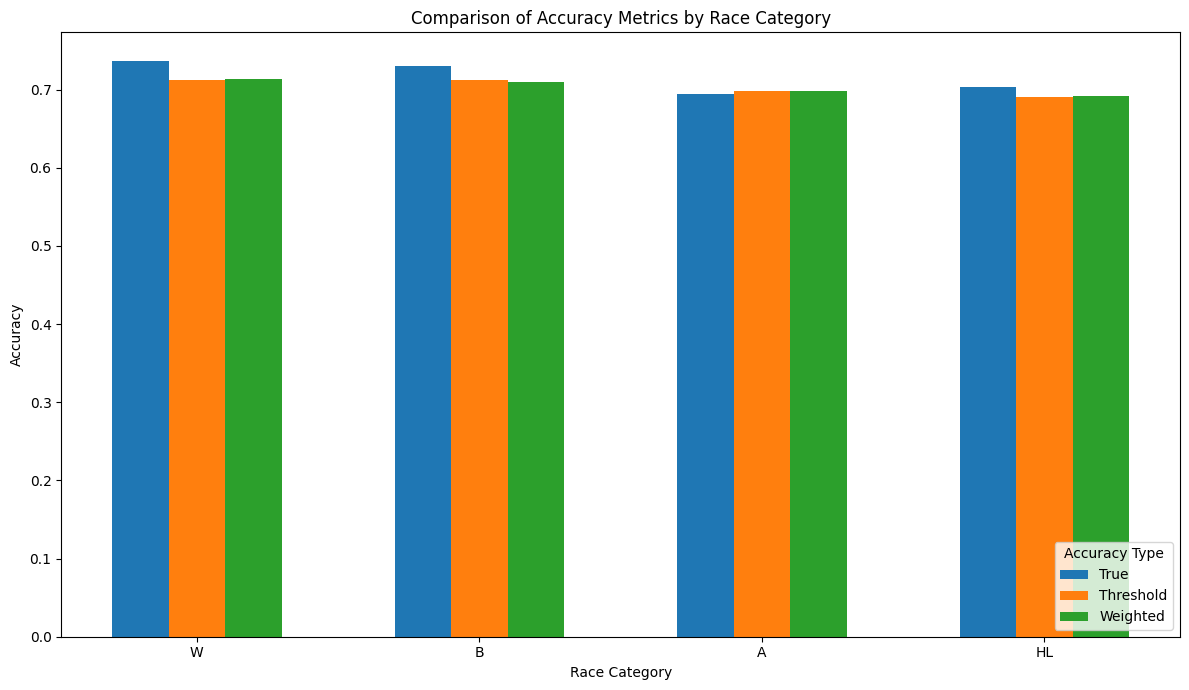

In [63]:
races = ["W", "B", "A", "HL"]
prob_cols = {
    "W": "prob_white",
    "B": "prob_black",
    "A": "prob_asian",
    "HL": "prob_hisp"
}

acc_true = accuracy_by_true_race(df, races)
acc_thresh = accuracy_by_bisg_thresh(df, races)
acc_weighted = accuracy_weighted_bisg(df, races, prob_cols)

final = pd.concat([acc_true, acc_thresh, acc_weighted], axis=1)
print(final)

import matplotlib.pyplot as plt
# import pandas as pd # pandas is already imported

races = final.index

bar_width = 0.2
index = range(len(races))

fig, ax = plt.subplots(figsize=(12, 7))

bar1 = ax.bar([i - bar_width for i in index], final['Accuracy_TrueRace'], bar_width, label='True')
bar2 = ax.bar(index, final['Accuracy_BISG_Threshold'], bar_width, label='Threshold')
bar3 = ax.bar([i + bar_width for i in index], final['Accuracy_WeightedBISG'], bar_width, label='Weighted')

ax.set_xlabel('Race Category')
ax.set_ylabel('Accuracy')
ax.set_title('Comparison of Accuracy Metrics by Race Category')
ax.set_xticks(index)
ax.set_xticklabels(races)
ax.legend(title='Accuracy Type', loc='lower right')

plt.tight_layout()
plt.show()

In [41]:
# table_thresh = final[[
#     "Accuracy_TrueRace",
#     "Accuracy_BISG_Threshold"
# ]].copy()

table_thresh = pd.concat([acc_true, acc_thresh], axis=1)

table_thresh["Difference_True_minus_Threshold"] = (
    table_thresh["Accuracy_TrueRace"] - table_thresh["Accuracy_BISG_Threshold"]
)

print(table_thresh)


    Accuracy_TrueRace  Accuracy_BISG_Threshold  \
W            0.736428                 0.714525   
B            0.730129                 0.715709   
A            0.694413                 0.698258   
HL           0.703501                 0.688753   

    Difference_True_minus_Threshold  
W                          0.021902  
B                          0.014419  
A                         -0.003844  
HL                         0.014748  


In [42]:
# table_weighted = final[[
#     "Accuracy_TrueRace",
#     "Accuracy_WeightedBISG"
# ]].copy()

table_weighted = pd.concat([acc_true, acc_weighted], axis=1)

table_weighted["Difference_True_minus_Weighted"] = (
    table_weighted["Accuracy_TrueRace"] - table_weighted["Accuracy_WeightedBISG"]
)

print(table_weighted)


    Accuracy_TrueRace  Accuracy_WeightedBISG  Difference_True_minus_Weighted
W            0.736428               0.713432                        0.022996
B            0.730129               0.709982                        0.020147
A            0.694413               0.697679                       -0.003265
HL           0.703501               0.692305                        0.011197


In [ ]:
table_weighted = pd.concat([acc_true, acc_weighted], axis=1)

table_weighted["Difference_True_minus_Weighted"] = (
    table_weighted["Accuracy_TrueRace"] - table_weighted["Accuracy_WeightedBISG"]
)

print(table_weighted)

## Visualize Accuracy Comparison

### Subtask:
Generate a grouped bar chart comparing Accuracy_TrueRace and Accuracy_WeightedBISG for each race category (W, B, A, HL) from table_weighted. Ensure the chart has appropriate labels and a legend.


**Reasoning**:
To visualize the comparison between `Accuracy_TrueRace` and `Accuracy_WeightedBISG`, I will create a grouped bar chart using `matplotlib.pyplot` as requested in the instructions.



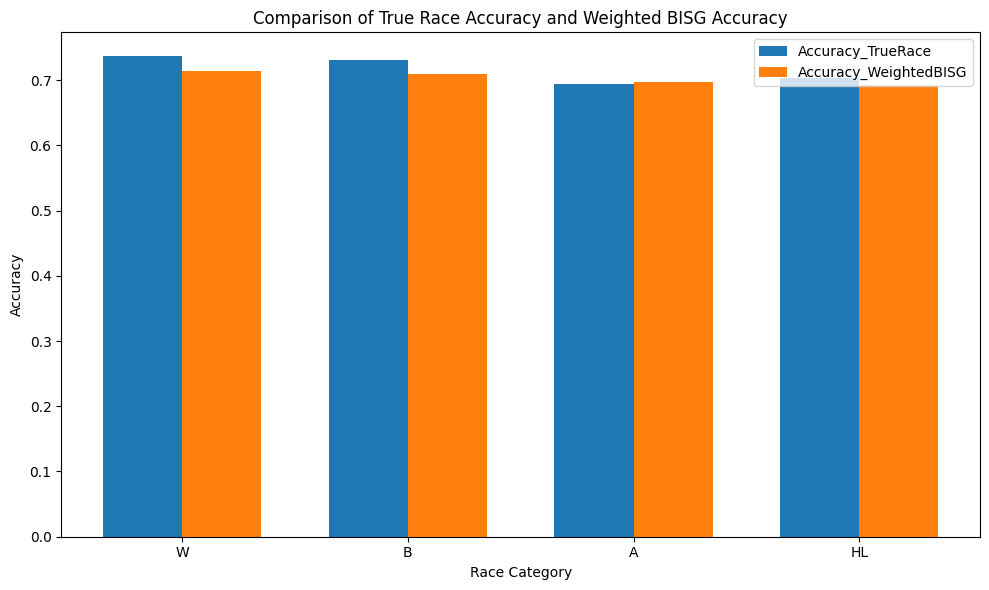

In [44]:
import matplotlib.pyplot as plt

races = table_weighted.index
accuracy_true = table_weighted['Accuracy_TrueRace']
accuracy_weighted = table_weighted['Accuracy_WeightedBISG']

bar_width = 0.35
index = range(len(races))

fig, ax = plt.subplots(figsize=(10, 6))

bar1 = ax.bar([i - bar_width/2 for i in index], accuracy_true, bar_width, label='Accuracy_TrueRace')
bar2 = ax.bar([i + bar_width/2 for i in index], accuracy_weighted, bar_width, label='Accuracy_WeightedBISG')

ax.set_xlabel('Race Category')
ax.set_ylabel('Accuracy')
ax.set_title('Comparison of True Race Accuracy and Weighted BISG Accuracy')
ax.set_xticks(index)
ax.set_xticklabels(races)
ax.legend()

plt.tight_layout()
plt.show()

## Visualize Accuracy Difference

### Subtask:
Generate a bar chart showing the Difference_True_minus_Weighted for each race category (W, B, A, HL) from table_weighted. Ensure the chart has appropriate labels.


## Summary:

### Data Analysis Key Findings
*   A grouped bar chart was successfully generated, comparing `Accuracy_TrueRace` and `Accuracy_WeightedBISG` for race categories W, B, A, and HL.
*   The chart provided a visual representation of how accuracy differs between true race and weighted BISG methods across these demographic groups.

### Insights or Next Steps
*   Further analysis of the generated chart is needed to quantify the specific accuracy differences between `Accuracy_TrueRace` and `Accuracy_WeightedBISG` for each racial category to understand the impact of using weighted BISG.
